# Heat Transfer
## Silicon: Transient Heat Transfer
Reading: Analytical Methods in Conduction Heat Transfer, G. E. Myers

### Heat equation

One-dimensional heat conduction. We can write the first law of thermodynamics as:

$$q|_x + g = q|_{x} = q|_{x+\Delta x} + \frac{dE}{dt}$$

where $g$ is thermal energy generation and $\frac{dE}{dt}$ is the rate of energy storage. We can then write Fourier's Law:

$$q|_x = -\left[k A \frac{\partial T}{\partial x} \right]_x $$

$$g = g''' (A \Delta x) $$

$$q|_{x+\Delta x} = -\left[k A \frac{\partial T}{\partial x} \right]_{x+\Delta x} $$

$$\frac{dE}{dt} = \rho (A \Delta x) c \frac{\partial T}{\partial t} $$

We can then write our energy balance:

$$-\left[k A \frac{\partial T}{\partial x} \right]_x  + g''' (A \Delta x) = -\left[k A \frac{\partial T}{\partial x} \right]_{x+\Delta x} + \rho (A \Delta x) c \frac{\partial T}{\partial t}$$

Dividing both sides by $\Delta x$, we have:

$$\frac{\left[k A \frac{\partial T}{\partial x} \right]_{x+\Delta x}-\left[k A \frac{\partial T}{\partial x} \right]_x}{\Delta x}  + g''' A =  \rho A c \frac{\partial T}{\partial t}$$

If $t$ and $T$ are independent variables, we have:

$$\frac{\partial}{\partial x} \left[ k A \frac{\partial T}{\partial x} \right]  + g''' A =  \rho A c \frac{\partial T}{\partial t}$$

If $A$ is a constant, then we can write:

$$\frac{\partial}{\partial x} \left[ k  \frac{\partial T}{\partial x} \right]  + g'''  =  \rho  c \frac{\partial T}{\partial t}$$

If $k$ is constant, we can write:

$$\frac{\partial^2 T}{\partial x^2}  + \frac{g'''}{k}  =  \frac{ \rho  c}{k} \frac{\partial T}{\partial t}$$

where $\alpha = \frac{k}{ \rho  c}$ is thermal diffusivity. In problems where the solid material is heterogeneous, $k$, $c$, and $\rho$ are not constant. For conduction in $y$ and $z$ we have:

$$\frac{\partial}{\partial x} \left[ k_x \frac{\partial T}{\partial x} \right] + \frac{\partial}{\partial y} \left[ k_y \frac{\partial T}{\partial y} \right] + \frac{\partial}{\partial z} \left[ k_z \frac{\partial T}{\partial z} \right]  + g''' =  \rho c \frac{\partial T}{\partial t}$$

### Heat generation

Reading: [Limits to the Energy Efficiency of CMOS Microprocessors](https://arxiv.org/pdf/2312.08595)

In modern complementary metal-oxide-semiconductor (CMOS) architecture, the heat generated in a floating point operation (FLOP) can be approximated by: 

$$g''' \approx \text{FLOPS} \cdot \text{Energy per FLOP}$$

One theoretical FLOP / J upper bound that applies to CMOS processors is derived from Landauer's principle, which posits that irreversible operations fundamentally release energy:

$$E \ge k_B T \ln 2 $$

where $T$ is temperature and $k_B$ is the Boltzmann constant (Ho 2023). If one has the number of bit erasures per floating point operation (FLOP), the Landauer limit allows one to estimate the maximum achievable FLOP per Joule. 

In [2]:
import math

T_K = 300
kB_JperK = 1.3806503e-23

E_min_J = kB_JperK*T_K*math.log(2)
E_min_aJ = E_min_J/1e-18

# an attojoule, aJ, is 10^-18 J. 
print("The minimum achievable energy per FLOP is then",f"{E_min_aJ}","aJ.")

The minimum achievable energy per FLOP is then 0.002870981588352728 aJ.


There are two contributors to energy dissipation in CMOS devices: Dynamic dissipation and static dissipation. The dynamic results from dynamic switching operations to change logic states or to communicate information. Static dissipation occurs without switching is primarily due to leakage currents. The key sources of energy dissipation can be classified as switching transistors, switching interconnect wire capacitances, short circuit power dissipation, static power, and information storage. Ho et al. suggests that half of the dynamic power dissipation is from wires and that interconnects dominate power dissipation. The reason is that the total length of interconnects has increased while the capacitance per unit length is independent of scale. Therefore, the total wire capacitance that needs to be charged per FLOP is larger. Ho et al. suggests that the maximum energy efficiency in FLOP / J of a CMOS processor is $4.7 \cdot 10^{15} $ FLOP / J. The energy efficiency of an NVIDIA H100 GPU for dense floating point operation is reported to be (10$^{15}$ FP16/s)/(700 W) $\approx 1.4 \cdot 10^{12}$ FP16/J = 1.4 FP16/pJ.

For an H100, the die area is approximately 814 mm$^2$. The silicon die thickness is approximately 0.775 mm. The volume is then:

In [2]:
WdotIn_W = 700
QdotOut_W = WdotIn_W
V_mm3 = 814*0.775
V_m3 = V_mm3/1000/1000/1000

g_WperM3 = QdotOut_W/V_m3
print("The volumetric heating rate in the silicon die is",f"{g_WperM3}","W/m3.")

The volumetric heating rate in the silicon die is 1109614012.8398192 W/m3.


That is a massive value. In reality, the volumetric heating rate is not uniform. There are hot spots that will have a significantly higher local heating rate (e.g., Tensor cores). For high-fidelity simulations, one may only consider the active transistor layer, which is quite thin (several micrometers). This could result in volumetric heating rates that are in the terawatt range. 

Since the volumetric heat generation is so large, there are specialized components to prevent the silicon from degrading:
1. Silicon die, which is the volumetric heat generation source.
2. Thermal interface material: liquid metal, which fills the gaps between the die and the next layer.
3. Integrated heat spreader (larger than the silicon die, composed of nickel coated copper; provides a flat surface which the fragile vapor chamber can be mounted onto).
4. Another thermal interface material.
5. Vapor chamber. Hollow vacuum-sealed copper chamber with a small amount of liquid that evaporates and condenses to spread heat across the entire base of the fins much faster than solid copper could.
6. A large array of metallic (copper) fins to maximize surface area.
7. Convective cooling. High-velocity air blown by server fans.

For the NVIDIA H100 (PCIe), this is able to use traditional fin-and-fan setup, because it only needs to dissipate 350 W of heat. The 700 W version (SXM5), many data centers are moving towards liquid cooling in order to achieve the necessary heat transfer coefficient to prevent overheating. In this case, a high-end liquid cold plate can be machined to match the topography of the GPU (direct-to-die cooling).

### Heat transfer from extended surfaces

Conservation of energy:

$$q_x = q_{x + dx} + dq_\text{conv} $$

From Fourier's law we know:

$$q_x = - k A_c \frac{dT}{dx}$$

where $A_c$ is the cross-sectional area. The conduction rate at $x + dx$ can be written as:

$$q_{x+dx} = q_x + \frac{dq_x}{dx}dx $$

We can then write:

$$q_{x+dx} = - k A_c \frac{dT}{dx} + \frac{d}{dx} \left( q_x \right)dx $$

$$q_{x+dx} = - k A_c \frac{dT}{dx} + \frac{d}{dx} \left( - k A_c \frac{dT}{dx} \right)dx $$

For constant values of thermal conductivity, we have:

$$q_{x+dx} = - k A_c \frac{dT}{dx} + - k \frac{d}{dx} \left(  A_c \frac{dT}{dx} \right)dx $$

Convection heat transfer can be expressed as:

$$dq_\text{conv} = h dA_s (T - T_{\infty}) $$

where $dA_s$ is the surface area of the differential element. Substituting the rate equations into the energy balance yields:

$$- k A_c \frac{dT}{dx} = - k A_c \frac{dT}{dx} + - k \frac{d}{dx} \left(  A_c \frac{dT}{dx} \right)dx + h dA_s (T - T_{\infty}) $$

Simplifying:

$$ k \frac{d}{dx} \left(  A_c \frac{dT}{dx} \right)dx - h dA_s (T - T_{\infty}) = 0$$

Dividing by $dx$:

$$ k \frac{d}{dx} \left(  A_c \frac{dT}{dx} \right) - h \frac{dA_s}{dx} (T - T_{\infty}) = 0$$

For a uniform fin geometry, $A_c = \text{const}$. 

$$ \frac{d^2T}{dx^2} - \frac{h}{k A_c} P \left(T - T_{\infty} \right) = 0$$

where $\frac{dA_s}{dx} = P$ is the perimeter of the fin. We can define an excess temperature, $\theta(x) = T(x) - T_{\infty}$, and 

$$m^2 = \frac{h}{k A_c} P$$

and write the above as:

$$ \frac{d^2 \theta}{dx^2} - m^2 \theta = 0$$

This is a linear, homogeneous, second-order differential equation. The general solution is of the form:

$$\theta(x) = C_1 \exp(mx) + C_2 \exp(-m x) $$

The boundary condition we are interested in is the following:

$$ h A_c [T(L) - T_{\infty}] = -k A_c \frac{dT}{dx}_{x=L}$$

$$ h \theta (L) = -k A_c \frac{d \theta}{dx}_{x=L}$$

We can define the temperature at the base of the fin as:

$$\theta (0) = T_b - T_\infty = \theta_b $$

We can write:

$$\theta_b = C_1 + C_2 $$

and

$$h (C_1 \exp(m L) + C_2 \exp(-m L)) = k m (C_2 \exp(-m L) - C_1 \exp(m L))$$

Solving for $C_1$ and $C_2$, we have:

$$\frac{\theta}{\theta_b} = \frac{\cosh m(L-x) + (h/(mk)) \sinh m(L-x)}{\cosh mL + (h/(mk)) \sinh mL}$$

In [3]:
import numpy as np
import matplotlib.pyplot as plt

Q_dot_W = 700.0        # Total Power (W)
# T_air = 35.0         # Ambient Air Temp (C)

# Silicon Die
A_die_m2 = 814e-6      
t_die_m = 775e-6       
k_die_WperMperK = 150.0       
g_WperM3 = Q_dot_W / (A_die_m2 * t_die_m)

# TIM 
t_tim1_m = 50e-6       # 50 um
k_tim1_WperMperK = 20.0        # W/m-K
A_tim1_m2 = A_die_m2
R_tim1_KperW = t_tim1_m/(k_tim1_WperMperK*A_tim1_m2); print("R_tim1_KperW=",R_tim1_KperW)

# IHS 
A_ihs_m2 = 2925e-6
t_ihs_m = 2.5e-3  
k_ihs_WperMperK = 400.0
R_ihs_KperW = t_ihs_m/(k_ihs_WperMperK*A_ihs_m2); print("R_ihs_KperW=",R_ihs_KperW)

# TIM 2
t_tim2_m2 = 100e-6      
k_tim2_WperMperK = 10.0 
A_tim2_m2 = A_ihs_m2
R_tim2_KperW = t_tim2_m2/(k_tim2_WperMperK*A_tim2_m2); print("R_tim2_KperW=",R_tim2_KperW)

# Vapor Chamber
R_vc_KperW = 0.002           # K/W 
t_vc_m = 4.0e-3        # 4 mm
A_vc_m2 = 9360e-6       # 9360 mm^2 (Heat rejection area)
k_vc_eff_WperMperK = t_vc_m / (R_vc_KperW * A_vc_m2); print("k_vc_eff_WperMperK=",k_vc_eff_WperMperK)

# Fins
H_fin_m = 0.04         # 40 mm height
h_WperM2PerK = 200.0            # (W/m^2-K)
k_fin_WperMperK = 400.0        # W/(m K)
N_fins = 70
t_fin_m = 0.0004       # m thickness
w_fin_m = 0.22         # m length
R_fin_KperW = t_fin_m/(k_fin_WperMperK*w_fin_m*t_fin_m*N_fins); print("R_fin_KperW=",R_fin_KperW)
P_m = 2*(t_fin_m + w_fin_m)
Ac_m2 = t_fin_m*w_fin_m

# Convective heat transfer
A_fin_m2 = N_fins*(2*H_fin_m*w_fin_m + t_fin_m*w_fin_m)#; print("A_fin_m2=",A_fin_m2)
R_conv_KperW = 1/(h_WperM2PerK*A_fin_m2); print("R_conv_KperW=",R_conv_KperW)

R_tim1_KperW= 0.003071253071253071
R_ihs_KperW= 0.002136752136752137
R_tim2_KperW= 0.003418803418803419
k_vc_eff_WperMperK= 213.67521367521368
R_fin_KperW= 0.00016233766233766234
R_conv_KperW= 0.0040382503069070225


qf_WperFin= 10.0
M= 1.7615992733876797
qratio= 0.9648524397168825
Tb_C= 25.88344879673913


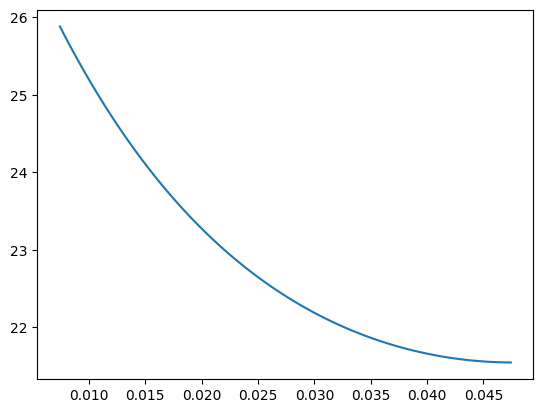

In [18]:
# determining fin temperatures
import numpy as np
import matplotlib.pyplot as plt

T_inf_C = 20

m2 = (h_WperM2PerK*P_m)/(k_fin_WperMperK*Ac_m2)
m = m2**0.5

L_m = t_die_m+t_tim1_m+t_ihs_m+t_tim2_m2+t_vc_m+H_fin_m
L = L_m
h = h_WperM2PerK
k = k_fin_WperMperK

xfin_m_ = np.linspace(0,H_fin_m,100)
xfin_m = xfin_m_ + t_die_m+t_tim1_m+t_ihs_m+t_tim2_m2+t_vc_m
thetaPerThetab_ = (np.cosh(m*(H_fin_m - xfin_m_)) + (h/(m*k))*np.sinh(m*(H_fin_m - xfin_m_)) )/(np.cosh(m*H_fin_m) + (h/(m*k))*np.sinh(m*H_fin_m))

qf_WperFin = Q_dot_W/N_fins; print("qf_WperFin=",qf_WperFin)

M = (h*P_m*k*Ac_m2)**(0.5); print("M=",M)

qratio = (np.sinh(m*H_fin_m) + (h/(m*k))*np.cosh(m*H_fin_m) )/(np.cosh(m*H_fin_m) + (h/(m*k))*np.sinh(m*H_fin_m) ); print("qratio=",qratio)
Tb_C = T_inf_C + qf_WperFin/(qratio*M); print("Tb_C=",Tb_C)

# T_fin_C_ = T_inf_C + (Tb_C-T_inf_C)*thetaPerThetab
T_fin_C__ = T_inf_C + (Tb_C - T_inf_C)*thetaPerThetab_

# plt.plot(xfin_m,T_fin_C_)
plt.plot(xfin_m,T_fin_C__)

T_vc_base_C= 27.28344879673913
T_tim2_base_C= 29.67661118990152
T_ihs_base_C= 31.17233768562802
T_tim1_base_C= 33.32221483550517


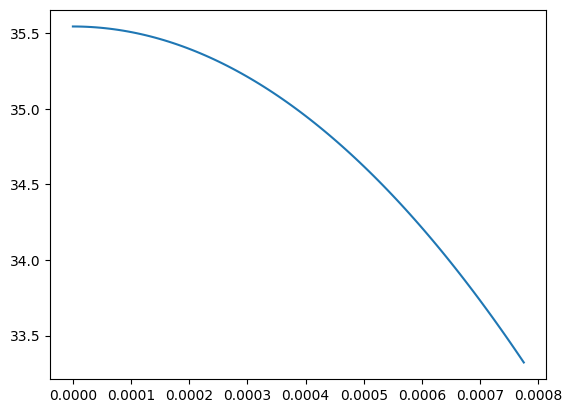

In [15]:

# T_fin_top_C = R_conv_KperW*Q_dot_W + T_inf_C; print("T_fin_top_C=",T_fin_top_C)
#T_fin_base_C = R_fin_KperW*Q_dot_W + T_fin_top_C; print("T_fin_base_C=",T_fin_base_C)

T_vc_base_C = R_vc_KperW*Q_dot_W + Tb_C; print("T_vc_base_C=",T_vc_base_C)
T_tim2_base_C = R_tim2_KperW*Q_dot_W + T_vc_base_C; print("T_tim2_base_C=",T_tim2_base_C)
T_ihs_base_C = R_ihs_KperW*Q_dot_W + T_tim2_base_C; print("T_ihs_base_C=",T_ihs_base_C)
T_tim1_base_C = R_tim1_KperW*Q_dot_W + T_ihs_base_C; print("T_tim1_base_C=",T_tim1_base_C)

x = np.linspace(0,t_die_m,100)
T_die_C = T_tim1_base_C + (1/2)*(g_WperM3/k_die_WperMperK)*(t_die_m**2 - x**2)
plt.plot(x,T_die_C)



Text(0, 0.5, 'T (deg. C)')

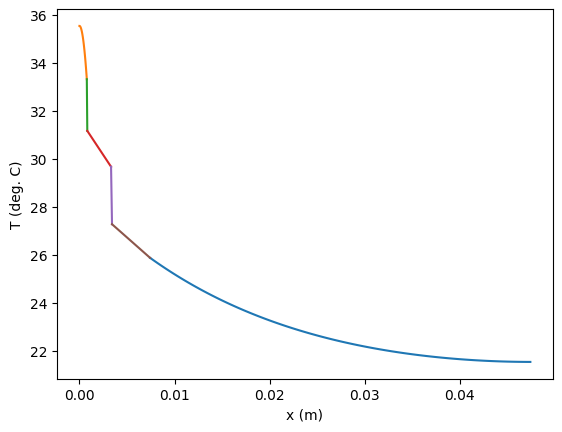

In [22]:
# temperature distribution

# t_die_m + t_tim1_m + t_ihs_m + t_tim2_m2 + t_vc_m + H_fin_m
plt.plot(xfin_m,T_fin_C__)
plt.plot(x,T_die_C)
plt.plot([t_die_m,t_die_m+t_tim1_m],[T_tim1_base_C,T_ihs_base_C])
plt.plot([t_die_m+t_tim1_m,t_die_m+t_tim1_m+t_ihs_m],[T_ihs_base_C,T_tim2_base_C])
plt.plot([t_die_m+t_tim1_m+t_ihs_m, t_die_m+t_tim1_m+t_ihs_m+t_tim2_m2],[T_tim2_base_C,T_vc_base_C])
plt.plot([t_die_m+t_tim1_m+t_ihs_m+t_tim2_m2, t_die_m+t_tim1_m+t_ihs_m+t_tim2_m2+t_vc_m],[T_vc_base_C,Tb_C])

plt.xlabel('x (m)')
plt.ylabel('T (deg. C)')